---
## Setup — Importing T1 from Task 2 Matrix Solver

Rather than redefining the datasets and solver here, we run `task2_matrix_solver.ipynb`
directly. That gives us:
- `data_set_1`, `data_set_2`, `data_set_3` — the 299-point outside temperature arrays
- `solve_temperature(theta_data)` — the matrix-based first-order T1 solver
- `all_datasets` — convenience dict mapping dataset names to arrays


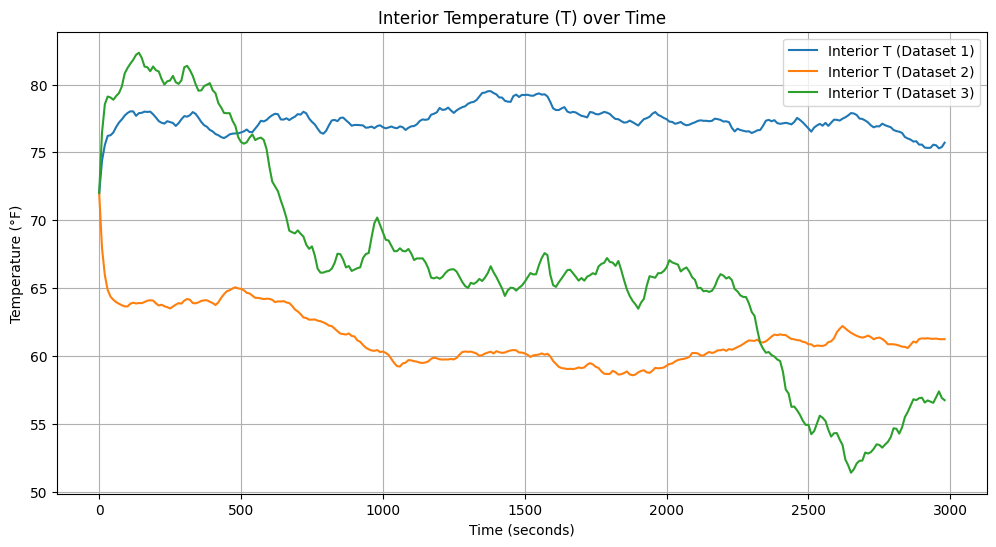

solve_first_order and helpers ready.


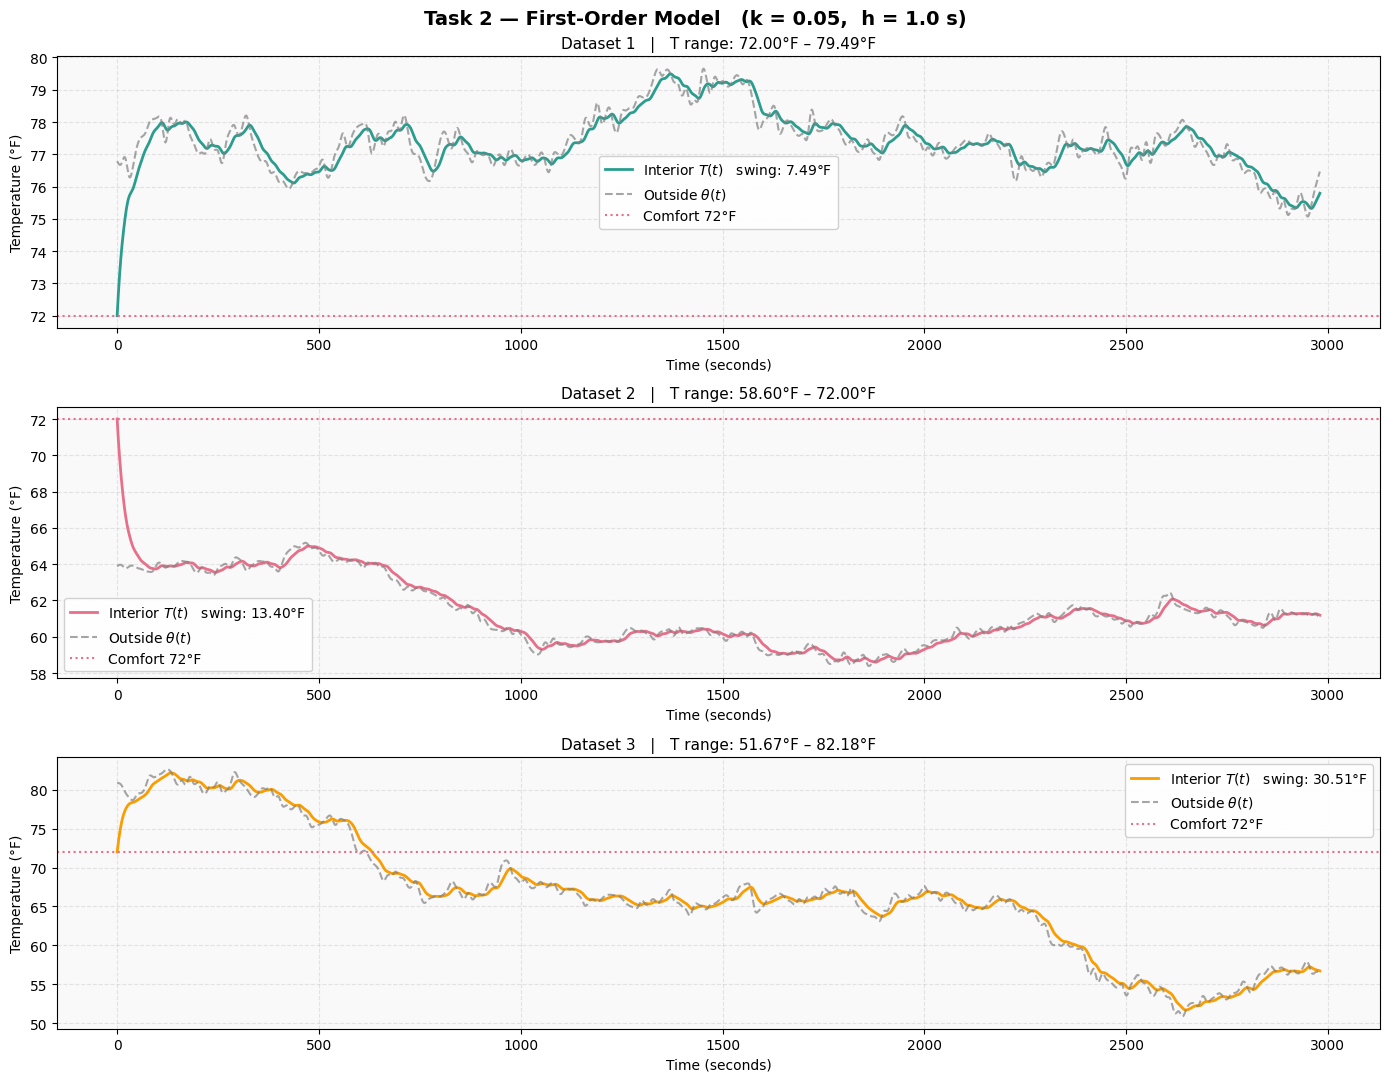

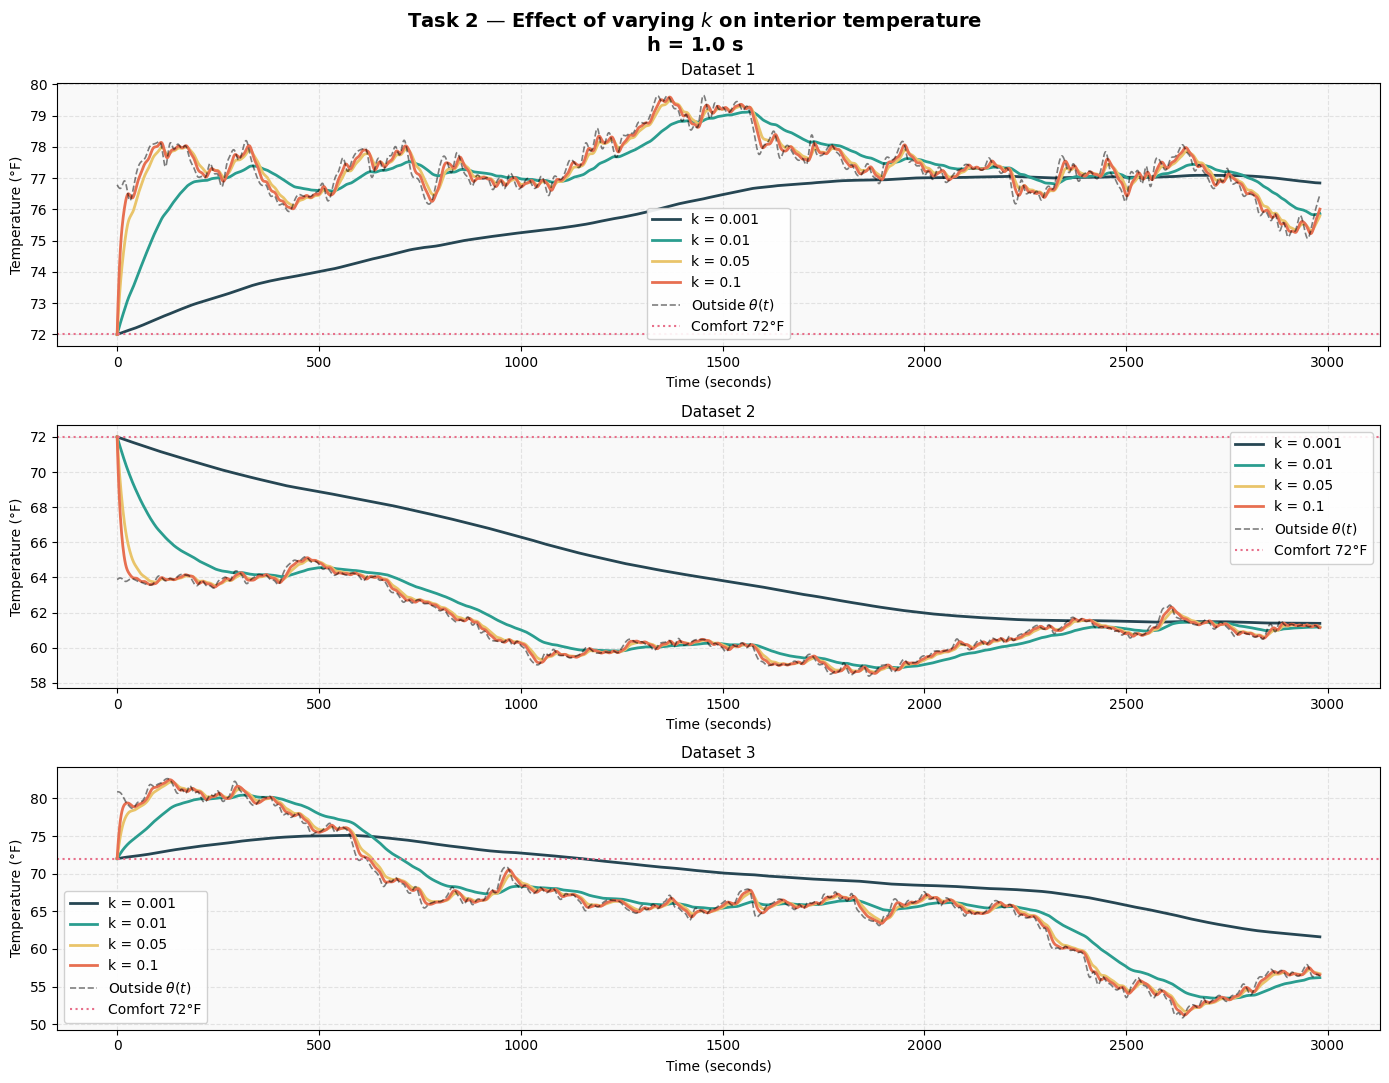

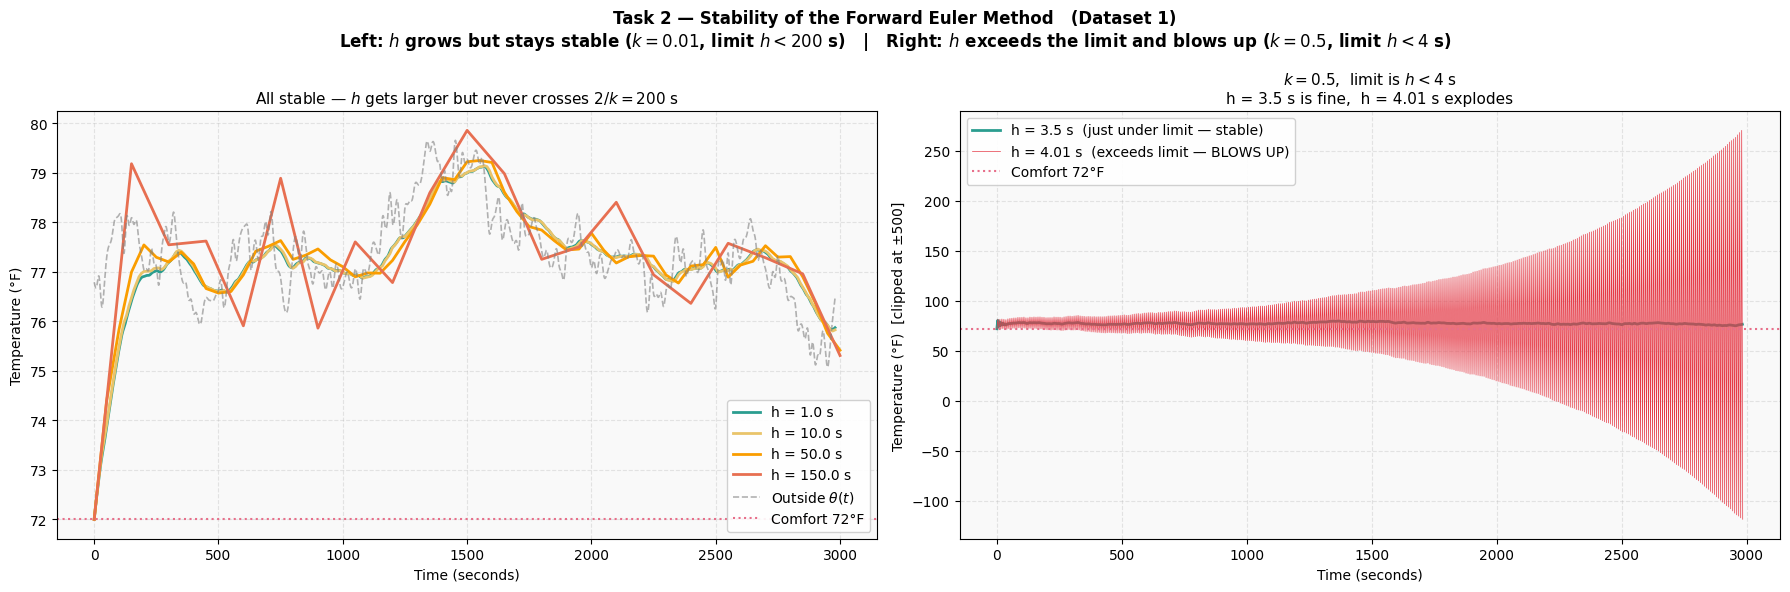

Left panel  — k = 0.01,  stability limit: h < 200 s
Right panel — k = 0.5,  stability limit: h < 4.0 s
h = 4.01 s exceeds the limit and blows up!
Task 2 matrix solver loaded.


In [1]:
import importlib, subprocess, sys
if importlib.util.find_spec('nbformat') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'nbformat', '-q'])

%run task2_matrix_solver.ipynb
print('Task 2 matrix solver loaded.')

The three datasets and `solve_temperature` are now available from Task 2.
The cell below shows a quick preview.

In [2]:
import pandas as pd

df = pd.DataFrame(
    [data_set_1, data_set_2, data_set_3],
    index=["Dataset 1", "Dataset 2", "Dataset 3"]
)
df.columns = [f"t={i*10}s" for i in range(df.shape[1])]
print(f"Datasets loaded: {df.shape[0]} datasets x {df.shape[1]} readings")
df.iloc[:, :5]

Datasets loaded: 3 datasets x 299 readings


,t=0s,t=10s,t=20s,t=30s,t=40s
Dataset 1,76.785250,76.697964,76.891343,76.301714,76.673130
Dataset 2,63.882035,63.960565,63.776995,63.878142,63.909248
Dataset 3,80.896119,80.644836,79.681065,78.971146,78.711085


---
# Task 4: Thermal Exposure

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.integrate import trapezoid

datasets      = [data_set_1, data_set_2, data_set_3]
dataset_names = ['Dataset 1', 'Dataset 2', 'Dataset 3']

Tc      = 72.0
k       = 0.05
h       = 1.0
dt_data = 10.0

PINK = '#E76F8A'
TEAL = '#2A9D8F'
GREY = '#A0A0A0'

print('Task 4 parameters ready!')

Task 4 parameters ready!


---
## Part 1: Thermal Exposure Using $T(t)$ from Task 2

Here we compute $E$ using the interior temperature from our **first-order
Forward Euler model**. Recall that this model assumes the interior reacts
instantly to outside changes, with no thermal inertia.

The three plots below show the shaded area between $T(t)$ and the $72^\circ$F
comfort line for each dataset. The total pink shaded area is $E$.

     PART 1 — THERMAL EXPOSURE USING T1 FROM TASK 2 MATRIX SOLVER     
Parameters: k = 0.05,  h = 1.0 s,  Tc = 72.0°F

Dataset 1:
  Method 1 — Trapezoidal (direct):      E = 15931.59 °F·s
  Method 3 — Cubic Spline:              E = 15931.60 °F·s
  Difference Methods 1 vs 3: 0.01 °F·s
  T range: 72.00°F – 79.49°F  |  Avg deviation: 5.346°F

Dataset 2:
  Method 1 — Trapezoidal (direct):      E = 31765.74 °F·s
  Method 3 — Cubic Spline:              E = 31765.76 °F·s
  Difference Methods 1 vs 3: 0.02 °F·s
  T range: 58.60°F – 72.00°F  |  Avg deviation: 10.660°F

Dataset 3:
  Method 1 — Trapezoidal (direct):      E = 24645.13 °F·s
  Method 3 — Cubic Spline:              E = 24645.15 °F·s
  Difference Methods 1 vs 3: 0.02 °F·s
  T range: 51.67°F – 82.18°F  |  Avg deviation: 8.270°F



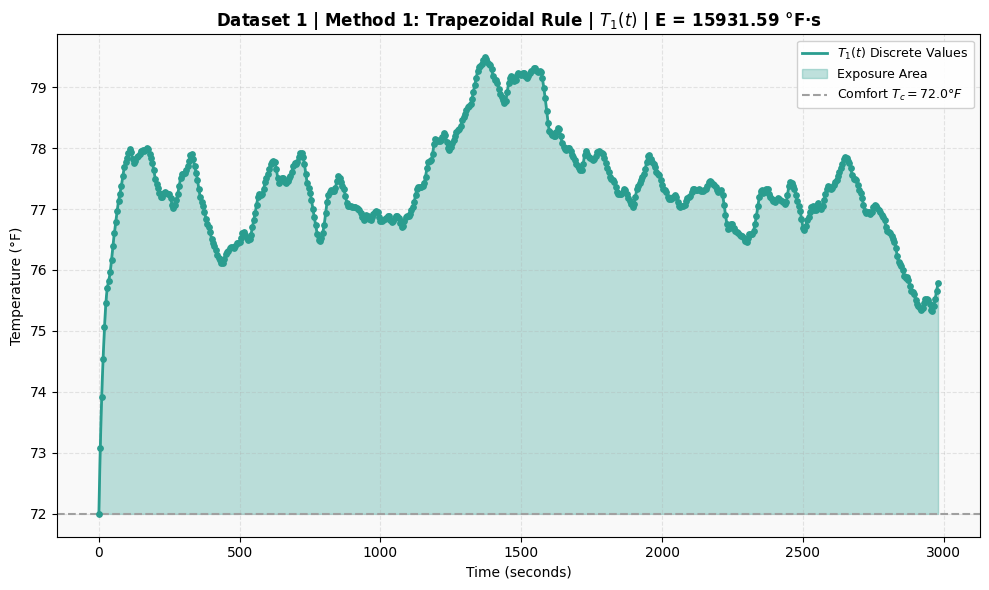

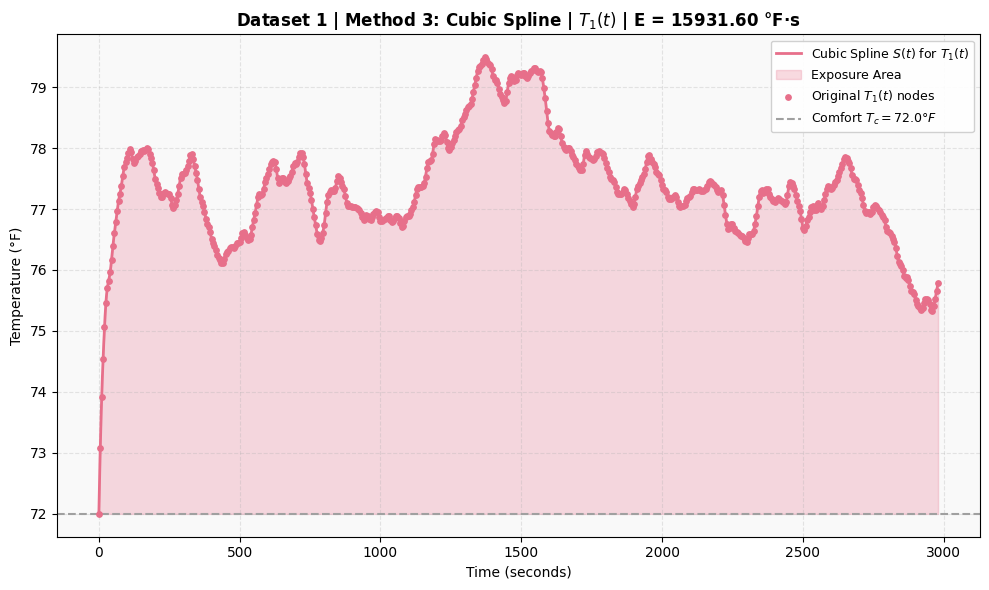

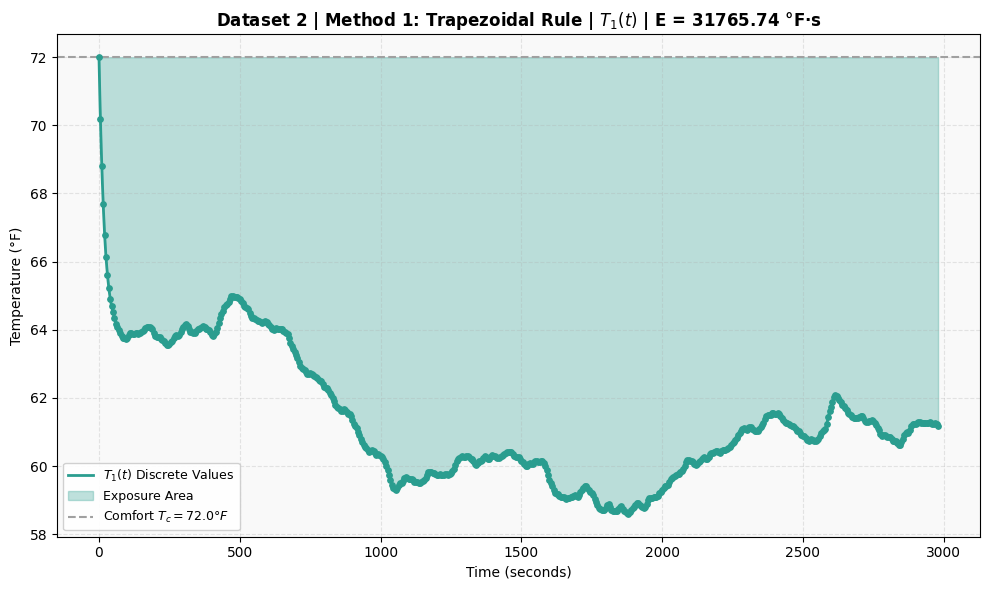

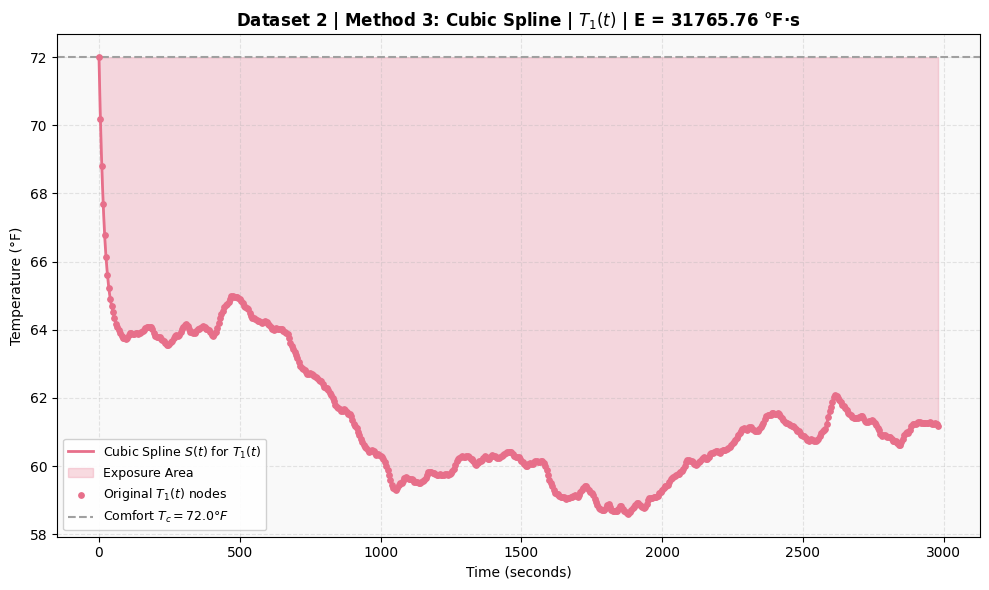

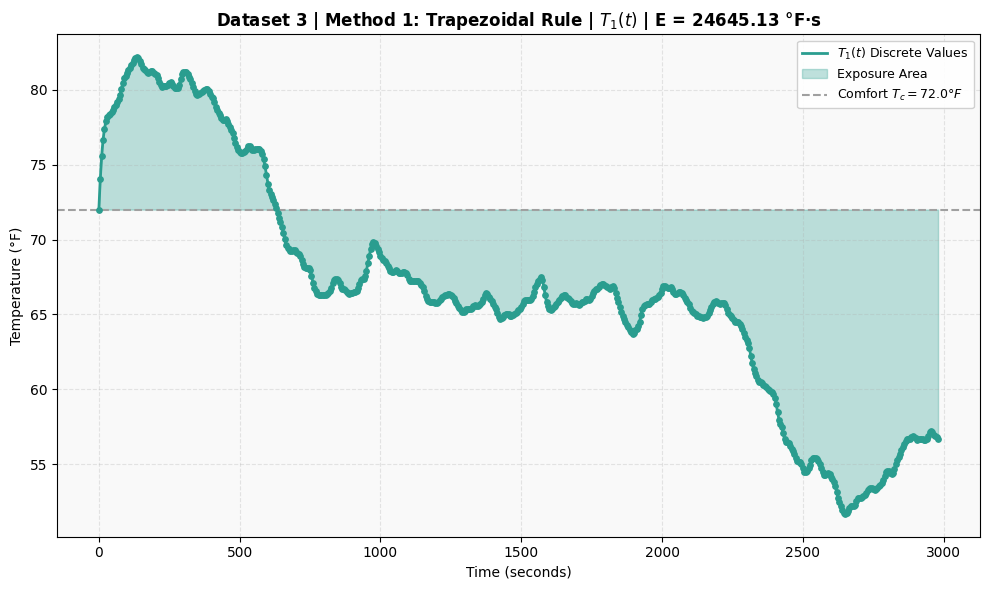

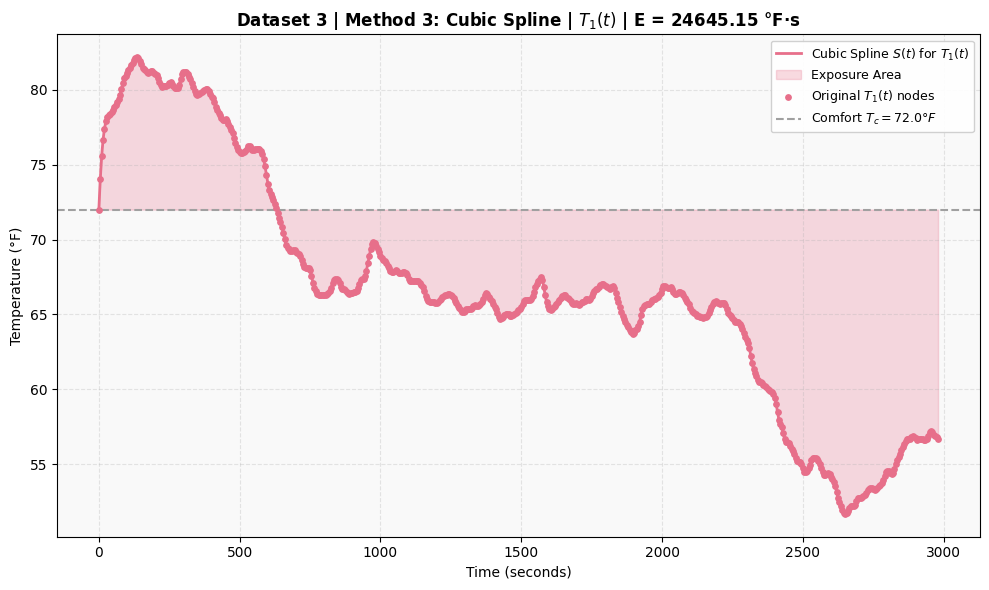

In [4]:
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import trapezoid

print('=' * 70)
print(f'{"PART 1 — THERMAL EXPOSURE USING T1 FROM TASK 2 MATRIX SOLVER":^70}')
print('=' * 70)
print(f'Parameters: k = {k},  h = {h} s,  Tc = {Tc}°F\n')

task2_results = []

for theta_data, name in zip(datasets, dataset_names):

    # Get T1 from the Task 2 matrix solver
    t2, T2 = solve_first_order(theta_data, h=h, k=k)

    # Method 1: trapezoidal rule directly on the discrete T(t) values
    E1 = trapezoid(np.abs(T2 - Tc), t2)

    # Method 3: natural cubic spline interpolant on a fine grid
    t_fine   = np.linspace(t2[0], t2[-1], 5000)
    cs_T2    = CubicSpline(t2, T2, bc_type='natural')
    T_spline = cs_T2(t_fine)
    E3 = trapezoid(np.abs(T_spline - Tc), t_fine)

    task2_results.append({
        'name'    : name,
        'E_trap'  : E1,
        'E_spline': E3,
        't'       : t2,
        'T'       : T2,
        'T_spline': T_spline,
        't_fine'  : t_fine
    })

    print(f'{name}:')
    print(f'  Method 1 — Trapezoidal (direct):      E = {E1:.2f} °F·s')
    print(f'  Method 3 — Cubic Spline:              E = {E3:.2f} °F·s')
    print(f'  Difference Methods 1 vs 3: {abs(E1-E3):.2f} °F·s')
    print(f'  T range: {T2.min():.2f}°F – {T2.max():.2f}°F  |  '
          f'Avg deviation: {E1/t2[-1]:.3f}°F\n')

for res in task2_results:
    t_sol    = res['t']
    T_sol    = res['T']
    t_fine   = res['t_fine']
    T_spline = res['T_spline']
    name     = res['name']
    E1, E3   = res['E_trap'], res['E_spline']

    # --- GRAPH 1: METHOD 1 (Trapezoidal Rule) ---
    plt.figure(figsize=(10, 6), facecolor='white')
    ax1 = plt.gca()
    ax1.set_facecolor('#F9F9F9')
    ax1.plot(t_sol, T_sol, color=TEAL, linewidth=2, label='$T_1(t)$ Discrete Values')
    ax1.fill_between(t_sol, T_sol, Tc, alpha=0.30, color=TEAL, label='Exposure Area')
    ax1.scatter(t_sol[::5], T_sol[::5], color=TEAL, s=15, zorder=5)
    ax1.axhline(Tc, color=GREY, linestyle='--', linewidth=1.5, label=f'Comfort $T_c={Tc}°F$')
    ax1.set_title(f'{name} | Method 1: Trapezoidal Rule | $T_1(t)$ | E = {E1:.2f} °F·s',
                  fontsize=12, fontweight='bold')
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Temperature (°F)')
    ax1.legend(framealpha=0.9, fontsize=9)
    ax1.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    # --- GRAPH 2: METHOD 3 (Cubic Spline Interpolation) ---
    plt.figure(figsize=(10, 6), facecolor='white')
    ax3 = plt.gca()
    ax3.set_facecolor('#F9F9F9')
    ax3.plot(t_fine, T_spline, color=PINK, linewidth=2, label='Cubic Spline $S(t)$ for $T_1(t)$')
    ax3.fill_between(t_fine, T_spline, Tc, alpha=0.25, color=PINK, label='Exposure Area')
    ax3.scatter(t_sol[::5], T_sol[::5], color=PINK, s=15, zorder=5, label='Original $T_1(t)$ nodes')
    ax3.axhline(Tc, color=GREY, linestyle='--', linewidth=1.5, label=f'Comfort $T_c={Tc}°F$')
    ax3.set_title(f'{name} | Method 3: Cubic Spline | $T_1(t)$ | E = {E3:.2f} °F·s',
                  fontsize=12, fontweight='bold')
    ax3.set_xlabel('Time (seconds)')
    ax3.set_ylabel('Temperature (°F)')
    ax3.legend(framealpha=0.9, fontsize=9)
    ax3.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

---
## Task 4, Part 2: Thermal Exposure from First-Order Model using Piecewise Lagrange Interpolation

       PART 2 — THERMAL EXPOSURE USING PIECEWISE LAGRANGE ON T1       
Parameters: k = 0.05, h = 1.0 s, Tc = 72.0°F


Dataset 1
  E (Piecewise Lagrange deg=3): 15931.57 °F·s


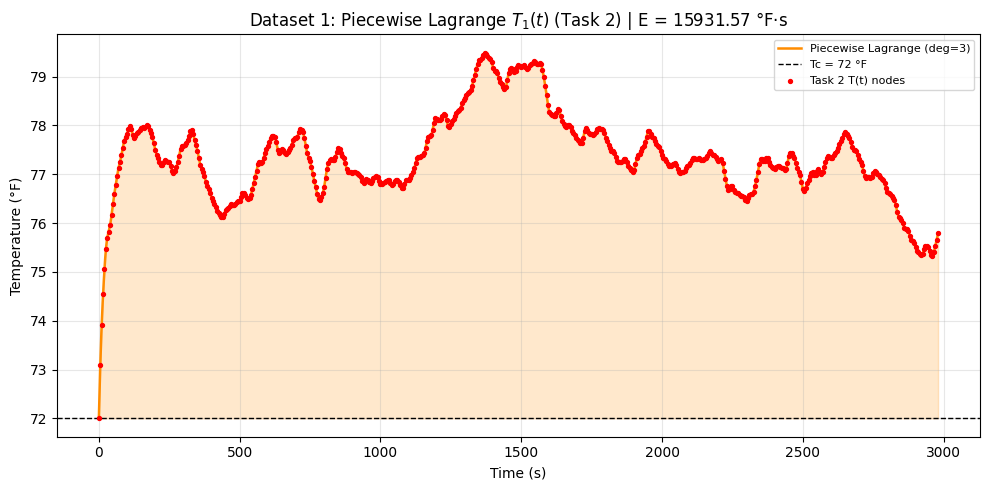


Dataset 2
  E (Piecewise Lagrange deg=3): 31765.70 °F·s


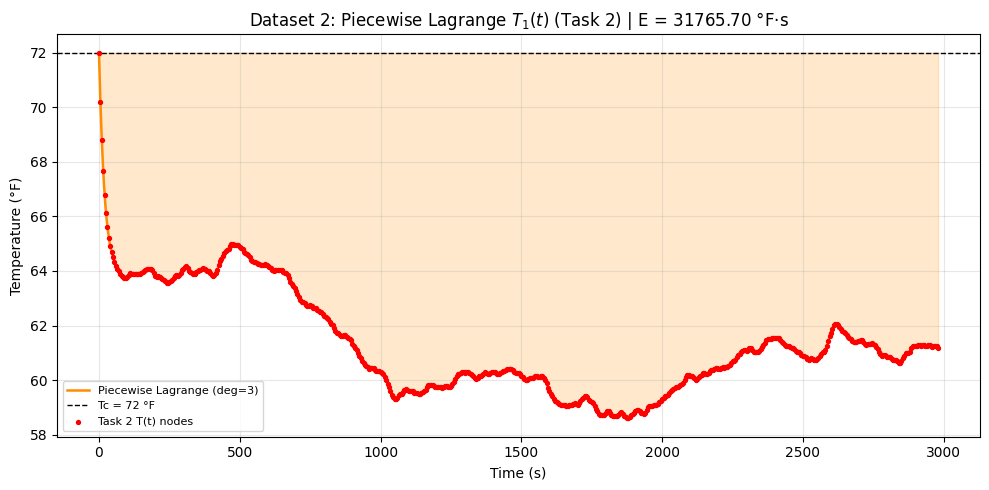


Dataset 3
  E (Piecewise Lagrange deg=3): 24645.09 °F·s


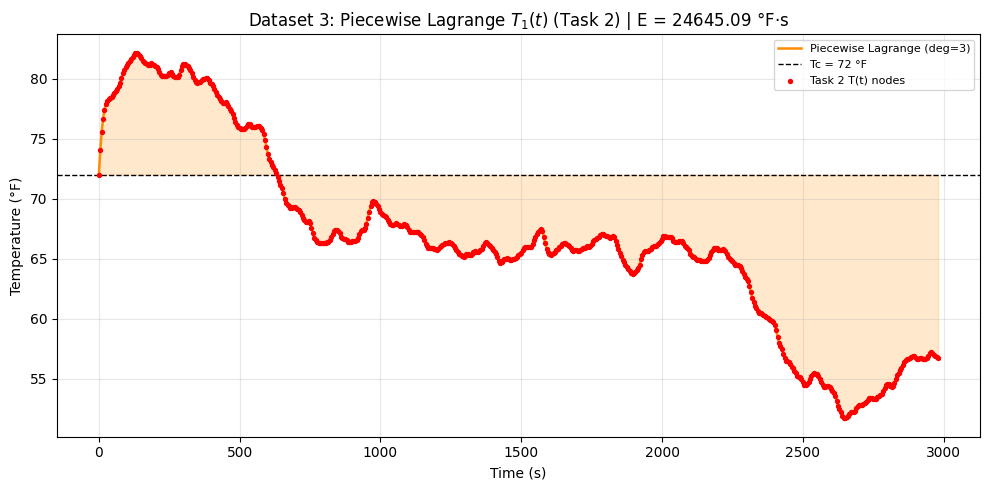

In [5]:
import matplotlib.pyplot as plt
import numpy as np

Tc = 72.0
k = 0.05
h = 1.0
piecewise_degree = 3


def lagrange_basis(t_val, i, t_nodes):
    result = 1.0
    for j in range(len(t_nodes)):
        if j != i:
            result *= (t_val - t_nodes[j]) / (t_nodes[i] - t_nodes[j])
    return result


def lagrange_interpolate(t_val, t_nodes, theta_nodes):
    return sum(
        float(theta_nodes[i]) * lagrange_basis(t_val, i, t_nodes)
        for i in range(len(t_nodes))
    )


def integrate_exposure(t_fine, P_fine):
    trapz = getattr(np, 'trapezoid', np.trapz)
    return trapz(np.abs(P_fine - Tc), t_fine)


def piecewise_lagrange(t_fine, t_nodes, T_nodes, degree=3):
    P_fine = np.zeros_like(t_fine)
    n = len(t_nodes)
    seg_size = degree + 1
    for start in range(0, n - 1, degree):
        end = min(start + seg_size, n)
        t_seg = t_nodes[start:end]
        T_seg = T_nodes[start:end]
        if len(t_seg) < 2:
            continue
        if start == 0:
            mask = (t_fine >= t_seg[0]) & (t_fine <= t_seg[-1])
        else:
            mask = (t_fine > t_seg[0]) & (t_fine <= t_seg[-1])
        for idx in np.where(mask)[0]:
            P_fine[idx] = lagrange_interpolate(t_fine[idx], t_seg, T_seg)
    return P_fine


print('=' * 70)
print(f'{"PART 2 — THERMAL EXPOSURE USING PIECEWISE LAGRANGE ON T1":^70}')
print('=' * 70)
print(f'Parameters: k = {k}, h = {h} s, Tc = {Tc}°F\n')

for theta_data, name in zip(datasets, dataset_names):
    print(f"\n{'=' * 55}")
    print(name)
    print(f"{'=' * 55}")

    # Get T1 from the Task 2 matrix solver
    t_nodes, T_nodes = solve_first_order(theta_data, h=h, k=k)

    t_fine = np.linspace(t_nodes[0], t_nodes[-1], 2000)

    P_piecewise = piecewise_lagrange(
        t_fine, t_nodes, T_nodes, degree=piecewise_degree
    )
    E_piecewise = integrate_exposure(t_fine, P_piecewise)

    print(f"  E (Piecewise Lagrange deg={piecewise_degree}): {E_piecewise:.2f} °F·s")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        t_fine, P_piecewise,
        color='darkorange', linewidth=1.8,
        label=f'Piecewise Lagrange (deg={piecewise_degree})',
    )
    ax.fill_between(t_fine, Tc, P_piecewise, alpha=0.2, color='darkorange')
    ax.axhline(Tc, color='black', linestyle='--', linewidth=1, label=f'Tc = {Tc:.0f} °F')
    ax.scatter(t_nodes[::5], T_nodes[::5], color='red', s=8, zorder=5, label='Task 2 T(t) nodes')
    ax.set_title(f'{name}: Piecewise Lagrange $T_1(t)$ (Task 2) | E = {E_piecewise:.2f} °F·s')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Temperature (°F)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()